<a href="https://colab.research.google.com/github/fabriciosgouveia/Fundamentos_de_Machine_Learning_com_ScikitLearn/blob/main/FabricioSebastiaoDeGouveia_Fundamentos_Machine_Learning_ScikitLearn_PD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Predição de Inadimplência de Cartão de Crédito
## Machine Learning Supervisionado com Scikit-Learn

**Dataset:** Default of Credit Card Clients (UCI)

**Objetivo:** Construir, avaliar e interpretar modelos supervisionados clássicos para predição de default (inadimplência) no mês seguinte.

---

## 1. Instalação e Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import tree, set_config
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold


import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Upload e Carregamento do Dataset

In [2]:
from google.colab import files
print('Aguardando upload do arquivo...')
uploaded = files.upload()

Aguardando upload do arquivo...


Saving default of credit card clients.xls to default of credit card clients.xls


In [3]:
import os
filename = list(uploaded.keys())[0]
print(f' Arquivo carregado: {filename}')

if filename.endswith('.csv'):
    df = pd.read_csv(filename)
elif filename.endswith('.xls') or filename.endswith('.xlsx'):
    df = pd.read_excel(filename, header=1)
else:
    print(' Formato não reconhecido. Use .csv ou .xls')

print(' Dataset carregado!')
print(f' Shape: {df.shape}')
df.head()

 Arquivo carregado: default of credit card clients.xls
 Dataset carregado!
 Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Análise Exploratória Inicial

In [4]:
print('ℹ Informações gerais do dataset:')
print(df.info())
print('\nℹ Estatísticas descritivas:')
print(df.describe())

ℹ Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   

In [5]:
print('ℹColunas disponíveis:')
print(df.columns.tolist())

if 'default.payment.next.month' in df.columns:
    df = df.rename(columns={'default.payment.next.month': 'default'})
elif 'default payment next month' in df.columns:
    df = df.rename(columns={'default payment next month': 'default'})

target_col = 'default'
print(f'\n Coluna alvo definida: {target_col}')

ℹColunas disponíveis:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

 Coluna alvo definida: default


Distribuição de Classes:
default
0    23364
1     6636
Name: count, dtype: int64

Proporção:
default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


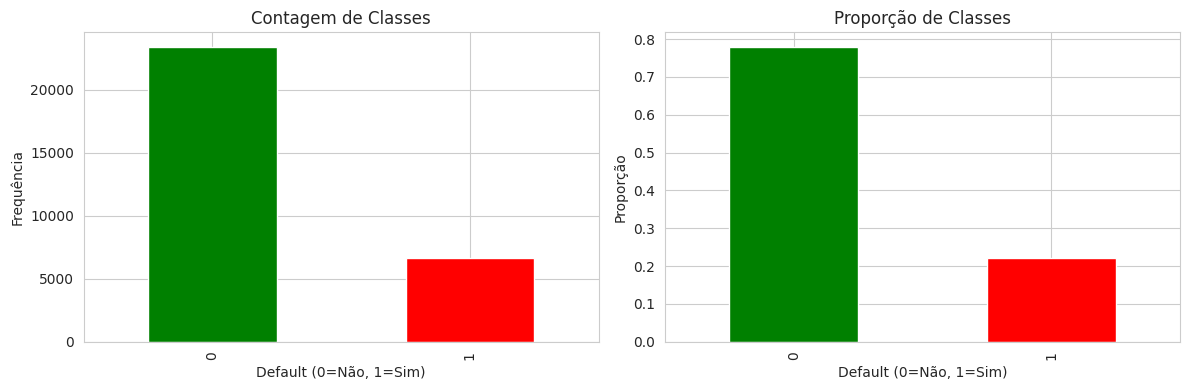

In [6]:
print('Distribuição de Classes:')
print(df[target_col].value_counts())
print('\nProporção:')
print(df[target_col].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Contagem de Classes')
ax[0].set_xlabel('Default (0=Não, 1=Sim)')
ax[0].set_ylabel('Frequência')

df[target_col].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['green', 'red'])
ax[1].set_title('Proporção de Classes')
ax[1].set_xlabel('Default (0=Não, 1=Sim)')
ax[1].set_ylabel('Proporção')
plt.tight_layout()
plt.show()

### Observações sobre desbalanceamento

O dataset apresenta **desbalanceamento de classes**, com a maioria dos clientes não entrando em default. Isso exige atenção especial às métricas **Precision, Recall e F1-score**.

## 4. Preparação dos Dados

In [7]:
X = df.drop(columns=[target_col])
y = df[target_col]

categorical_cols = [col for col in ['SEX', 'EDUCATION', 'MARRIAGE'] if col in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print(f'Features separadas!')
print(f'Categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f' Numéricas ({len(numeric_cols)}): {numeric_cols}')

Features separadas!
Categóricas (3): ['SEX', 'EDUCATION', 'MARRIAGE']
 Numéricas (21): ['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [8]:
total_ausentes = X.isnull().sum().sum()
if total_ausentes == 0:
    print(' Nenhum valor ausente encontrado!')
else:
    print(f' Total de valores ausentes: {total_ausentes}')
    print(X.isnull().sum()[X.isnull().sum() > 0])

 Nenhum valor ausente encontrado!


## 5. Split Treino/Teste

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(' Dados divididos com sucesso!')
print(f' Treino: {X_train.shape[0]} amostras')
print(f' Teste:  {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino:')
print(y_train.value_counts(normalize=True))
print(f'\nDistribuição no teste:')
print(y_test.value_counts(normalize=True))

 Dados divididos com sucesso!
 Treino: 24000 amostras
 Teste:  6000 amostras

Distribuição no treino:
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Distribuição no teste:
default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


## 6. Pipeline de Pré-processamento

O pipeline abaixo replica exatamente o diagrama do projeto:
- **SimpleImputer**: preenche valores ausentes
- **KNNImputer**: imputação por vizinhos mais próximos (numéricas)
- **OneHotEncoder**: encoding de categóricas
- **StandardScaler**: padronização de numéricas
- **remainder passthrough**: mantém colunas sem transformação

In [10]:
# Ativa visualização do diagrama
set_config(display='diagram')

# Pipeline para colunas NUMÉRICAS
numeric_pipeline = Pipeline(steps=[
    ('simple_imputer', SimpleImputer(strategy='median')),
    ('knn_imputer',    KNNImputer(n_neighbors=5)),
    ('standardscale',  StandardScaler())
])

# Pipeline para colunas CATEGÓRICAS
categorical_pipeline = Pipeline(steps=[
    ('simple_imputer',  SimpleImputer(strategy='most_frequent')),
    ('onehotencoder',   OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      numeric_pipeline,      numeric_cols),
        ('categorical',  categorical_pipeline,  categorical_cols)
    ],
    remainder='passthrough'
)

print(' Preprocessor criado com sucesso!')

 Preprocessor criado com sucesso!


In [11]:
#  diagrama do pipeline
meu_projeto = Pipeline(steps=[
    ('preprocessors', preprocessor)
])

meu_projeto

Pipeline(steps=[('preprocessors',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('knn_imputer',
                                                                   KNNImputer()),
                                                                  ('standardscale',
                                                                   StandardScaler())]),
                                                  ['ID', 'LIMIT_BAL', 'AGE',
                                                   'PAY_0', 'PAY_2', 'PAY_3',
                                                   'PAY_4', 'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                                 ('categorical',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])]))])

## 7. Funções Auxiliares de Avaliação

In [12]:
def print_metrics(y_true, y_pred, title='Modelo'):
    print(f"\n{'='*60}")
    print(f"{title:^60}")
    print('='*60)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print('='*60)

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Default', 'Default'])
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

print('Funções auxiliares definidas!')

Funções auxiliares definidas!


---
# PARTE 1: MODELO BASELINE - PERCEPTRON
---

O **Perceptron** é um classificador linear clássico que aprende um hiperplano separador no espaço das features. Serve como **baseline** porque:
- Tem baixa complexidade computacional
- Fornece coeficientes lineares explícitos
- Estabelece ponto de comparação para modelos mais sofisticados

In [13]:
print(' Treinando modelo Perceptron (baseline)...')

perceptron_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   Perceptron(random_state=42, max_iter=1000))
])

perceptron_pipeline.fit(X_train, y_train)

y_pred_train_perc = perceptron_pipeline.predict(X_train)
y_pred_test_perc  = perceptron_pipeline.predict(X_test)

print(' Perceptron treinado!')

 Treinando modelo Perceptron (baseline)...
 Perceptron treinado!


 Avaliando Perceptron...

                    PERCEPTRON - TREINO                     
Accuracy : 0.7215
Precision: 0.3964
Recall   : 0.4954
F1-score : 0.4404

                     PERCEPTRON - TESTE                     
Accuracy : 0.7098
Precision: 0.3741
Recall   : 0.4635
F1-score : 0.4140

=== Classification Report (Teste) ===
              precision    recall  f1-score   support

 Não Default       0.84      0.78      0.81      4673
     Default       0.37      0.46      0.41      1327

    accuracy                           0.71      6000
   macro avg       0.61      0.62      0.61      6000
weighted avg       0.73      0.71      0.72      6000



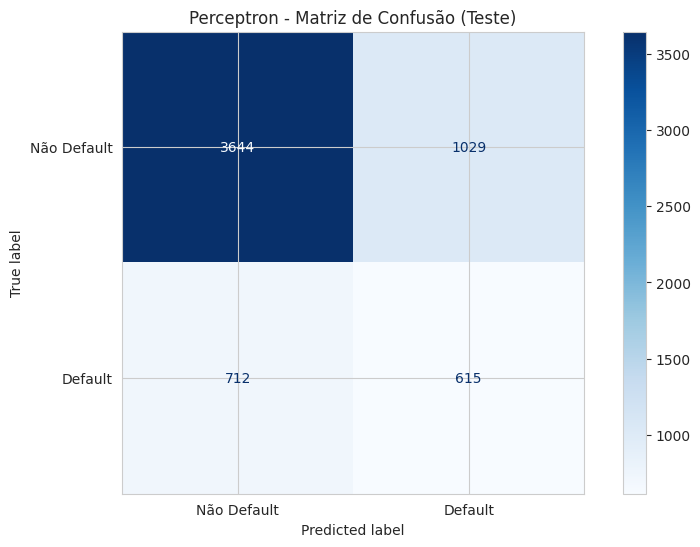

In [14]:
print(' Avaliando Perceptron...')
print_metrics(y_train, y_pred_train_perc, 'PERCEPTRON - TREINO')
print_metrics(y_test,  y_pred_test_perc,  'PERCEPTRON - TESTE')

print('\n=== Classification Report (Teste) ===')
print(classification_report(y_test, y_pred_test_perc,
                            target_names=['Não Default', 'Default'],
                            zero_division=0))

plot_confusion_matrix(y_test, y_pred_test_perc, 'Perceptron - Matriz de Confusão (Teste)')

ℹ Extraindo coeficientes do Perceptron...

Bias (w0): -21.0000

Top 10 Features mais influentes:
    Feature  Coeficiente
   PAY_AMT2   -12.742513
  BILL_AMT3    -9.554759
   PAY_AMT4    -8.402845
EDUCATION_5    -7.000000
 MARRIAGE_1     7.000000
  BILL_AMT4    -6.421884
 MARRIAGE_2     6.000000
      PAY_2     5.992902
         ID    -5.158332
      PAY_4     4.606248


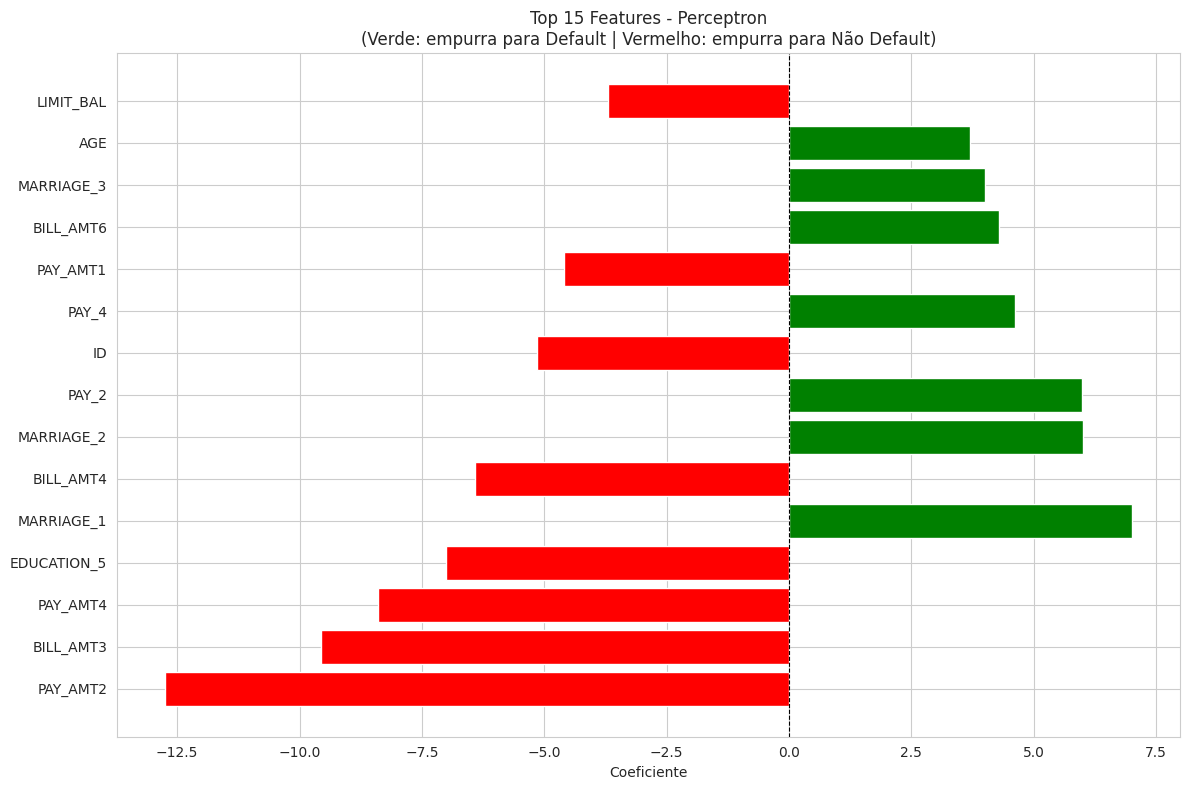

 Interpretação do Perceptron concluída!


In [15]:
print('ℹ Extraindo coeficientes do Perceptron...')

perceptron_model     = perceptron_pipeline.named_steps['classifier']
preprocessor_fitted  = perceptron_pipeline.named_steps['preprocessor']

feature_names_transformed = list(numeric_cols)

if categorical_cols:
    cat_encoder = preprocessor_fitted.named_transformers_['categorical'].named_steps['onehotencoder']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    feature_names_transformed.extend(cat_feature_names)

coef = perceptron_model.coef_[0]
bias = perceptron_model.intercept_[0]

coef_df = pd.DataFrame({
    'Feature':     feature_names_transformed[:len(coef)],
    'Coeficiente': coef
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print(f'\nBias (w0): {bias:.4f}')
print('\nTop 10 Features mais influentes:')
print(coef_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
top_features = coef_df.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['Coeficiente']]
plt.barh(top_features['Feature'], top_features['Coeficiente'], color=colors)
plt.xlabel('Coeficiente')
plt.title('Top 15 Features - Perceptron\n(Verde: empurra para Default | Vermelho: empurra para Não Default)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

print(' Interpretação do Perceptron concluída!')

---
# PARTE 2: ÁRVORE DE DECISÃO
---

In [16]:
print(' Treinando Árvore de Decisão (simples)...')

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_train_dt = dt_pipeline.predict(X_train)
y_pred_test_dt  = dt_pipeline.predict(X_test)

print(' Árvore de Decisão (simples) treinada!')

 Treinando Árvore de Decisão (simples)...
 Árvore de Decisão (simples) treinada!


 Avaliando Árvore de Decisão (simples)...

              DECISION TREE (SIMPLES) - TREINO              
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              DECISION TREE (SIMPLES) - TESTE               
Accuracy : 0.7265
Precision: 0.3917
Recall   : 0.4280
F1-score : 0.4091

=== Classification Report (Teste) ===
              precision    recall  f1-score   support

 Não Default       0.83      0.81      0.82      4673
     Default       0.39      0.43      0.41      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.62      0.62      6000
weighted avg       0.74      0.73      0.73      6000



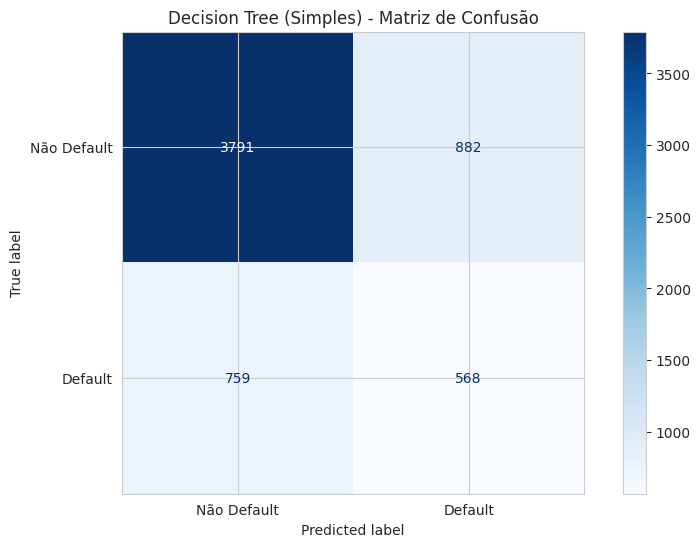

In [17]:
print(' Avaliando Árvore de Decisão (simples)...')
print_metrics(y_train, y_pred_train_dt, 'DECISION TREE (SIMPLES) - TREINO')
print_metrics(y_test,  y_pred_test_dt,  'DECISION TREE (SIMPLES) - TESTE')

print('\n=== Classification Report (Teste) ===')
print(classification_report(y_test, y_pred_test_dt,
                            target_names=['Não Default', 'Default'],
                            zero_division=0))

plot_confusion_matrix(y_test, y_pred_test_dt, 'Decision Tree (Simples) - Matriz de Confusão')

Gerando visualização da Árvore de Decisão...


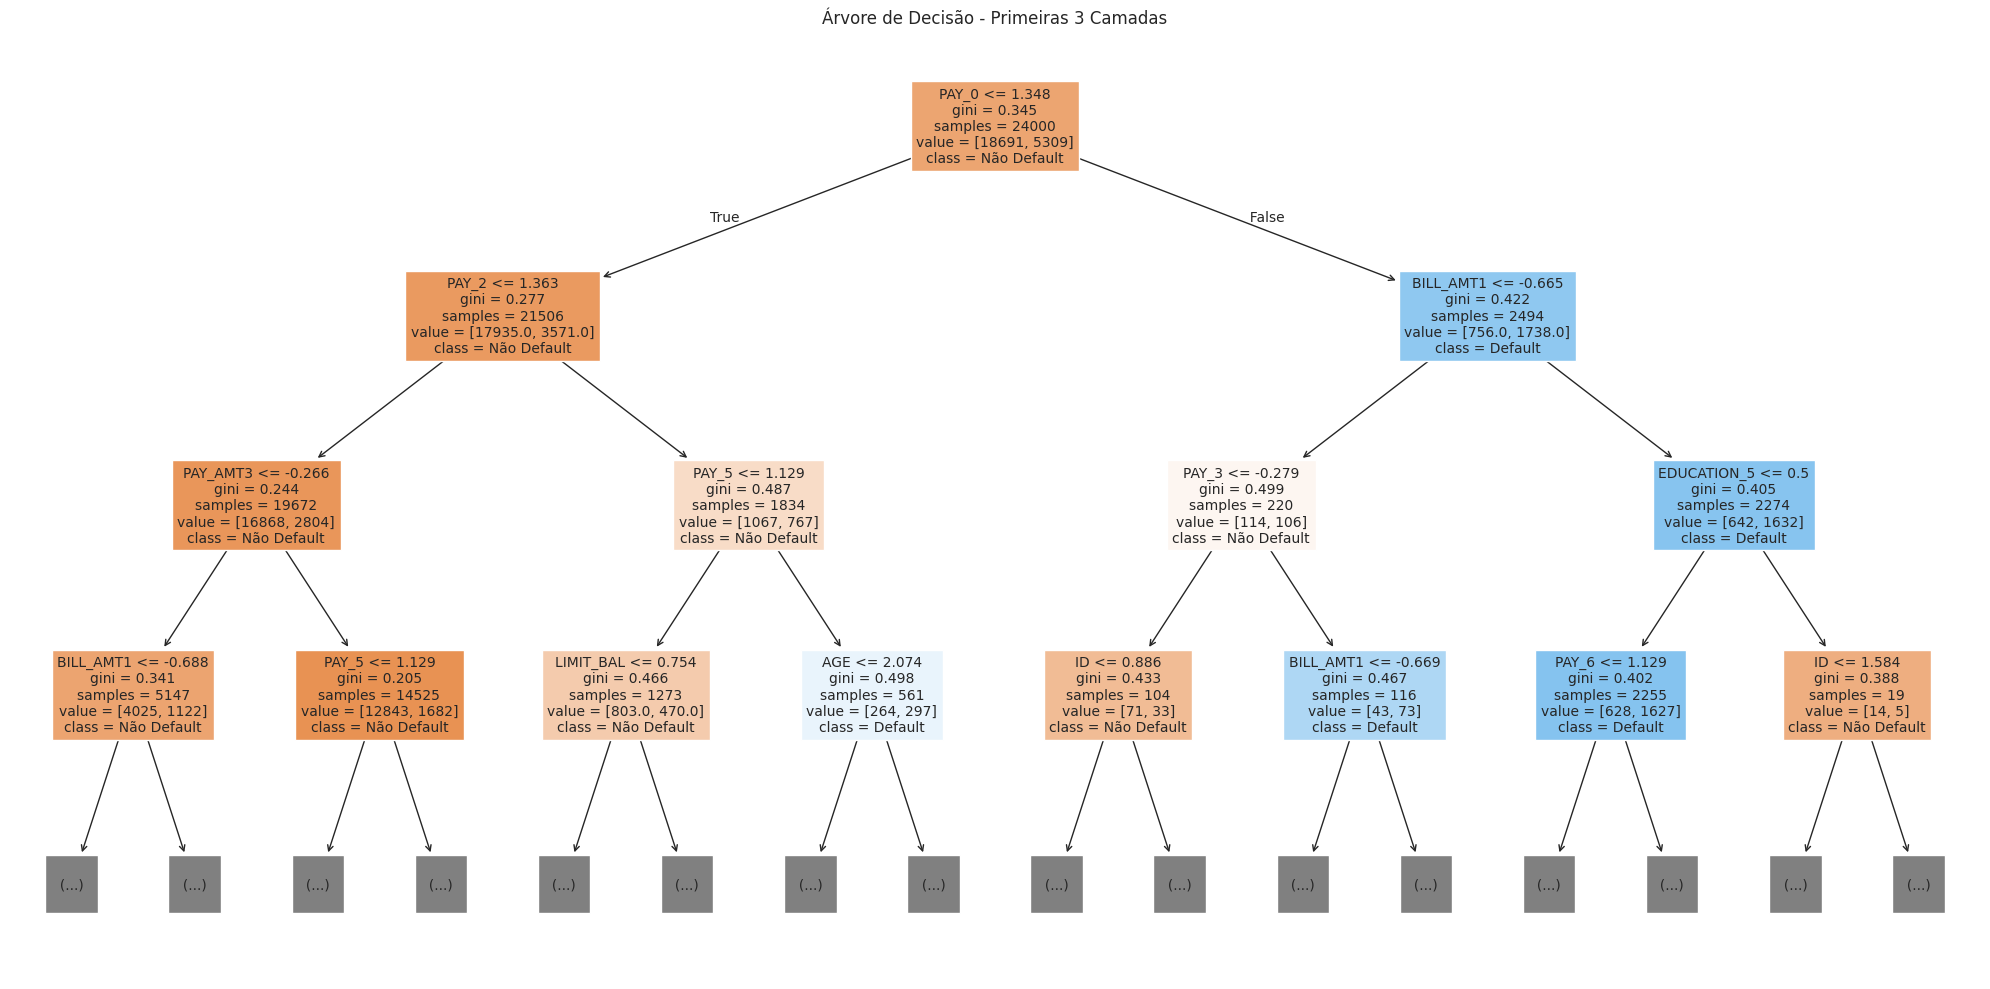

 Profundidade da árvore: 43
 Número de folhas: 3544


In [18]:
print('Gerando visualização da Árvore de Decisão...')

dt_model = dt_pipeline.named_steps['classifier']

# Nomes das features após preprocessamento
feature_names_tree = list(numeric_cols)
if categorical_cols:
    cat_enc = dt_pipeline.named_steps['preprocessor'].named_transformers_['categorical'].named_steps['onehotencoder']
    feature_names_tree.extend(cat_enc.get_feature_names_out(categorical_cols))

plt.figure(figsize=(20, 10))
tree.plot_tree(dt_model,
               feature_names=feature_names_tree,
               class_names=['Não Default', 'Default'],
               filled=True,
               max_depth=3,
               fontsize=10)
plt.title('Árvore de Decisão - Primeiras 3 Camadas')
plt.tight_layout()
plt.show()

print(f' Profundidade da árvore: {dt_model.get_depth()}')
print(f' Número de folhas: {dt_model.get_n_leaves()}')

---
# PARTE 3: VALIDAÇÃO CRUZADA E OTIMIZAÇÃO
---

In [19]:



# Grid reduzido para ser mais rápido (recomendado)
param_grid_dt = {
    'classifier__max_depth':         [3, 5, 10, None],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf':  [1, 5, 10],
    'classifier__criterion':         ['gini', 'entropy']
}

total_combinacoes = np.prod([len(v) for v in param_grid_dt.values()])
n_folds = 5
total_fits = total_combinacoes * n_folds

print(f'Combinações de hiperparâmetros : {total_combinacoes}')
print(f'Folds de validação cruzada     : {n_folds}')
print(f'Total de fits a executar       : {total_fits}')
print('='*60)

cv_strategy = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

dt_pipeline_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=42))
])

# verbose=3 mostra cada fit individualmente
grid_search_dt = GridSearchCV(
    estimator=dt_pipeline_base,
    param_grid=param_grid_dt,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1,         # <-- coloca 1 para os prints aparecerem em ordem
    verbose=3,        # <-- mostra cada fold + candidato
    return_train_score=True
)

print('Iniciando Grid Search para Árvore de Decisão...')
print('='*60)

inicio = time.time()
grid_search_dt.fit(X_train, y_train)
fim = time.time()

tempo_total = fim - inicio
print('='*60)
print(f' Grid Search concluído!')
print(f' Tempo total: {tempo_total:.1f} segundos ({tempo_total/60:.1f} minutos)')
print(f' Melhor F1-Score (CV): {grid_search_dt.best_score_:.4f}')
print(f' Melhores parâmetros:')
for param, value in grid_search_dt.best_params_.items():
    print(f'   {param}: {value}')

Combinações de hiperparâmetros : 72
Folds de validação cruzada     : 5
Total de fits a executar       : 360
Iniciando Grid Search para Árvore de Decisão...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END classifier__criterion=gini, classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__min_samples_split=2;, score=(train=0.484, test=0.487) total time=   0.3s
[CV 2/5] END classifier__criterion=gini, classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__min_samples_split=2;, score=(train=0.484, test=0.493) total time=   0.3s
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__min_samples_split=2;, score=(train=0.486, test=0.478) total time=   0.2s
[CV 4/5] END classifier__criterion=gini, classifier__max_depth=3, classifier__min_samples_leaf=1, classifier__min_samples_split=2;, score=(train=0.484, test=0.487) total time=   0.2s
[CV 5/5] END classifier__criterion=gini, classifie

In [20]:
print('\n' + '='*80)
print('RESULTADOS DO GRID SEARCH')
print('='*80)
print('\n Melhores hiperparâmetros:')
for param, value in grid_search_dt.best_params_.items():
    print(f'  {param}: {value}')
print(f'\n Melhor F1-Score médio (CV): {grid_search_dt.best_score_:.4f}')

best_dt = grid_search_dt.best_estimator_
y_pred_train_dt_opt = best_dt.predict(X_train)
y_pred_test_dt_opt  = best_dt.predict(X_test)


RESULTADOS DO GRID SEARCH

 Melhores hiperparâmetros:
  classifier__criterion: gini
  classifier__max_depth: 3
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 2

 Melhor F1-Score médio (CV): 0.4846


Avaliando Árvore Otimizada...

             DECISION TREE (OTIMIZADA) - TREINO             
Accuracy : 0.8230
Precision: 0.6811
Recall   : 0.3762
F1-score : 0.4846

             DECISION TREE (OTIMIZADA) - TESTE              
Accuracy : 0.8185
Precision: 0.6608
Recall   : 0.3685
F1-score : 0.4731

=== Classification Report (Teste) ===
              precision    recall  f1-score   support

 Não Default       0.84      0.95      0.89      4673
     Default       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



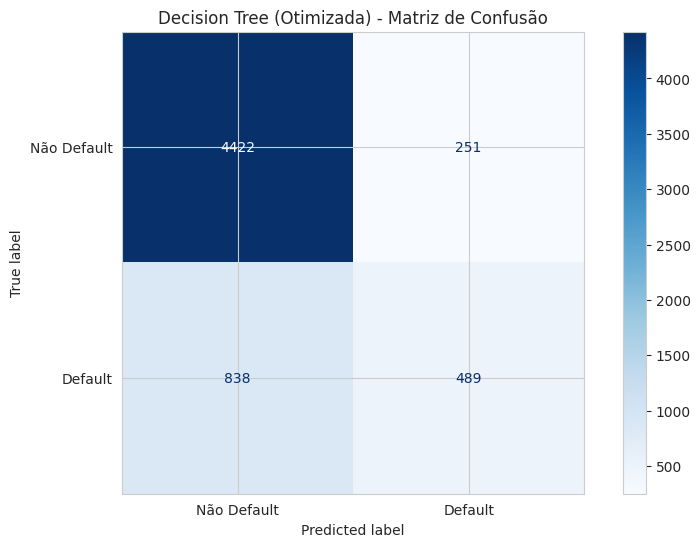

In [21]:
print('Avaliando Árvore Otimizada...')
print_metrics(y_train, y_pred_train_dt_opt, 'DECISION TREE (OTIMIZADA) - TREINO')
print_metrics(y_test,  y_pred_test_dt_opt,  'DECISION TREE (OTIMIZADA) - TESTE')

print('\n=== Classification Report (Teste) ===')
print(classification_report(y_test, y_pred_test_dt_opt,
                            target_names=['Não Default', 'Default'],
                            zero_division=0))

plot_confusion_matrix(y_test, y_pred_test_dt_opt, 'Decision Tree (Otimizada) - Matriz de Confusão')

 Analisando robustez (variação entre folds)...

Top 10 configurações:
  Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
  Test:  0.4846 (+/- 0.0055)
  Train: 0.4852

  Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
  Test:  0.4846 (+/- 0.0055)
  Train: 0.4852

  Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 20}
  Test:  0.4846 (+/- 0.0055)
  Train: 0.4852

  Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
  Test:  0.4846 (+/- 0.0055)
  Train: 0.4852

  Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10}
  Test:  0.4846 (+/- 0.0055)

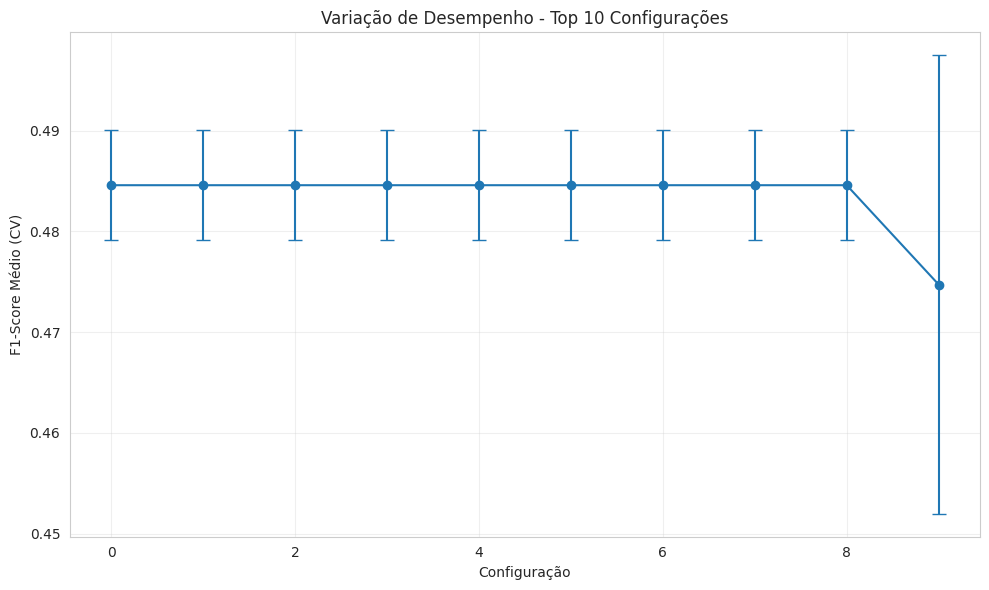

 Análise de robustez concluída!


In [22]:
print(' Analisando robustez (variação entre folds)...')

cv_results  = pd.DataFrame(grid_search_dt.cv_results_)
top_configs = cv_results.nsmallest(10, 'rank_test_score')[[
    'params', 'mean_test_score', 'std_test_score', 'mean_train_score'
]]

print('\nTop 10 configurações:')
for _, row in top_configs.iterrows():
    print(f"  Params: {row['params']}")
    print(f"  Test:  {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Train: {row['mean_train_score']:.4f}\n")

plt.figure(figsize=(10, 6))
plt.errorbar(range(len(top_configs)),
             top_configs['mean_test_score'],
             yerr=top_configs['std_test_score'],
             fmt='o-', capsize=5)
plt.xlabel('Configuração')
plt.ylabel('F1-Score Médio (CV)')
plt.title('Variação de Desempenho - Top 10 Configurações')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(' Análise de robustez concluída!')

---
# PARTE 4: RANDOM FOREST
---

In [24]:
param_dist_rf = {
    'classifier__n_estimators':      [100, 200, 300],
    'classifier__max_depth':         [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf':  [1, 2, 5, 10],
    'classifier__max_features':      ['sqrt', 'log2', 0.5]
}

n_iter   = 10
n_folds  = 5
total_fits = n_iter * n_folds

print(f'Combinações sorteadas (n_iter) : {n_iter}')
print(f'Folds de validação cruzada     : {n_folds}')
print(f'Total de fits a executar       : {total_fits}')
print('='*60)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_jobs=1))
])

random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=n_iter,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1,          # <-- 1 para prints aparecerem em ordem
    random_state=42,
    verbose=3,         # <-- mostra cada fold + candidato
    return_train_score=True
)

print('⏳ Iniciando Random Search para Random Forest...')
print('='*60)

inicio = time.time()
random_search_rf.fit(X_train, y_train)
fim = time.time()

tempo_total = fim - inicio

print('='*60)
print(f'Random Forest otimizado com sucesso!')
print(f'Tempo total: {tempo_total:.1f} segundos ({tempo_total/60:.1f} minutos)')
print(f'Melhor F1-Score (CV): {random_search_rf.best_score_:.4f}')
print(f'Melhores parâmetros:')
for param, value in random_search_rf.best_params_.items():
    print(f'   {param}: {value}')

best_rf         = random_search_rf.best_estimator_
y_pred_train_rf = best_rf.predict(X_train)
y_pred_test_rf  = best_rf.predict(X_test)

Combinações sorteadas (n_iter) : 10
Folds de validação cruzada     : 5
Total de fits a executar       : 50
⏳ Iniciando Random Search para Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END classifier__max_depth=15, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__n_estimators=200;, score=(train=0.655, test=0.473) total time=  22.8s
[CV 2/5] END classifier__max_depth=15, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__n_estimators=200;, score=(train=0.666, test=0.475) total time=  16.5s
[CV 3/5] END classifier__max_depth=15, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__n_estimators=200;, score=(train=0.664, test=0.470) total time=  16.2s
[CV 4/5] END classifier__max_depth=15, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_spli

In [25]:
print('\n' + '='*80)
print('RESULTADOS - RANDOM FOREST')
print('='*80)
print('\n Melhores hiperparâmetros:')
for param, value in random_search_rf.best_params_.items():
    print(f'  {param}: {value}')
print(f'\n Melhor F1-Score médio (CV): {random_search_rf.best_score_:.4f}')

best_rf = random_search_rf.best_estimator_
y_pred_train_rf = best_rf.predict(X_train)
y_pred_test_rf  = best_rf.predict(X_test)


RESULTADOS - RANDOM FOREST

 Melhores hiperparâmetros:
  classifier__n_estimators: 100
  classifier__min_samples_split: 2
  classifier__min_samples_leaf: 2
  classifier__max_features: 0.5
  classifier__max_depth: 15

 Melhor F1-Score médio (CV): 0.4776


 Avaliando Random Forest...

                   RANDOM FOREST - TREINO                   
Accuracy : 0.9007
Precision: 0.9513
Recall   : 0.5809
F1-score : 0.7213

                   RANDOM FOREST - TESTE                    
Accuracy : 0.8162
Precision: 0.6543
Recall   : 0.3580
F1-score : 0.4627

=== Classification Report (Teste) ===
              precision    recall  f1-score   support

 Não Default       0.84      0.95      0.89      4673
     Default       0.65      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.79      6000



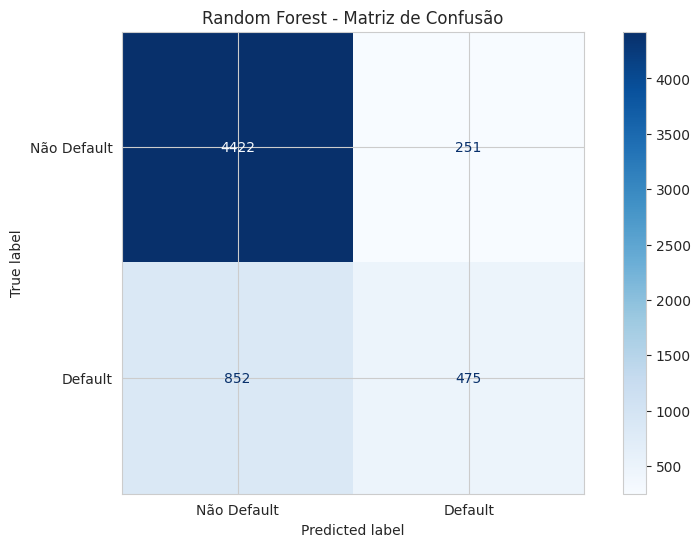

In [26]:
print(' Avaliando Random Forest...')
print_metrics(y_train, y_pred_train_rf, 'RANDOM FOREST - TREINO')
print_metrics(y_test,  y_pred_test_rf,  'RANDOM FOREST - TESTE')

print('\n=== Classification Report (Teste) ===')
print(classification_report(y_test, y_pred_test_rf,
                            target_names=['Não Default', 'Default'],
                            zero_division=0))

plot_confusion_matrix(y_test, y_pred_test_rf, 'Random Forest - Matriz de Confusão')

 Gerando importância das features...

Top 15 Features:
  Feature  Importance
    PAY_0    0.196029
    PAY_2    0.078379
       ID    0.063610
BILL_AMT1    0.049214
      AGE    0.047582
LIMIT_BAL    0.044461
 PAY_AMT2    0.041489
 PAY_AMT3    0.040511
 PAY_AMT1    0.038685
BILL_AMT2    0.037198
 PAY_AMT6    0.036953
 PAY_AMT5    0.036601
BILL_AMT6    0.036291
BILL_AMT3    0.034649
 PAY_AMT4    0.034005


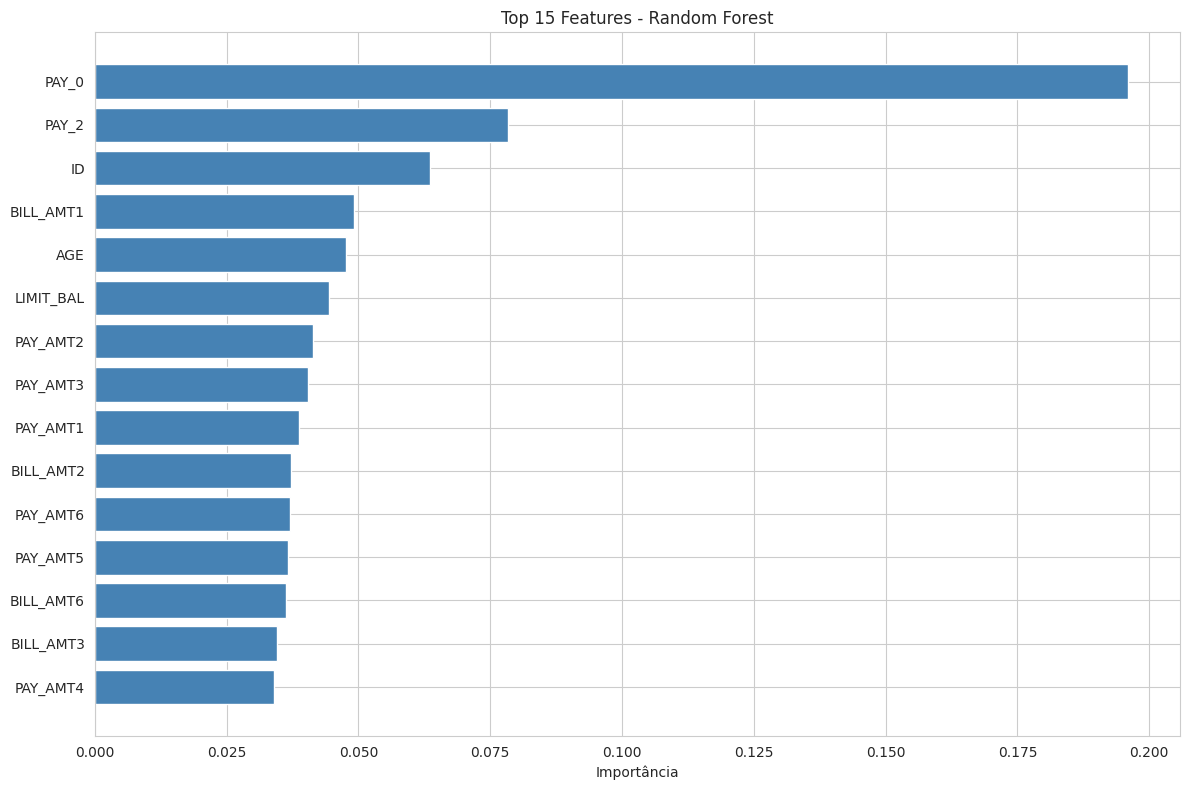

 Importância das features gerada!


In [28]:
print(' Gerando importância das features...')

rf_model    = best_rf.named_steps['classifier']
importances = rf_model.feature_importances_

feature_names_rf = list(numeric_cols)
if categorical_cols:
    cat_enc_rf = best_rf.named_steps['preprocessor'].named_transformers_['categorical'].named_steps['onehotencoder']
    feature_names_rf.extend(cat_enc_rf.get_feature_names_out(categorical_cols))

importance_df = pd.DataFrame({
    'Feature':    feature_names_rf[:len(importances)],
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('\nTop 15 Features:')
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
top_15 = importance_df.head(15)
plt.barh(top_15['Feature'], top_15['Importance'], color='steelblue')
plt.xlabel('Importância')
plt.title('Top 15 Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(' Importância das features gerada!')

---
# COMPARAÇÃO FINAL DE TODOS OS MODELOS
---

📊 Gerando comparação final de todos os modelos...

COMPARAÇÃO FINAL - TODOS OS MODELOS
          Modelo Conjunto  Accuracy  Precision   Recall  F1-Score
      Perceptron   Treino  0.721542   0.396443 0.495385  0.440425
      Perceptron    Teste  0.709833   0.374088 0.463451  0.414002
  Árvore Simples   Treino  1.000000   1.000000 1.000000  1.000000
  Árvore Simples    Teste  0.726500   0.391724 0.428033  0.409075
Árvore Otimizada   Treino  0.823042   0.681105 0.376154  0.484650
Árvore Otimizada    Teste  0.818500   0.660811 0.368500  0.473149
   Random Forest   Treino  0.900708   0.951265 0.580900  0.721319
   Random Forest    Teste  0.816167   0.654270 0.357950  0.462737


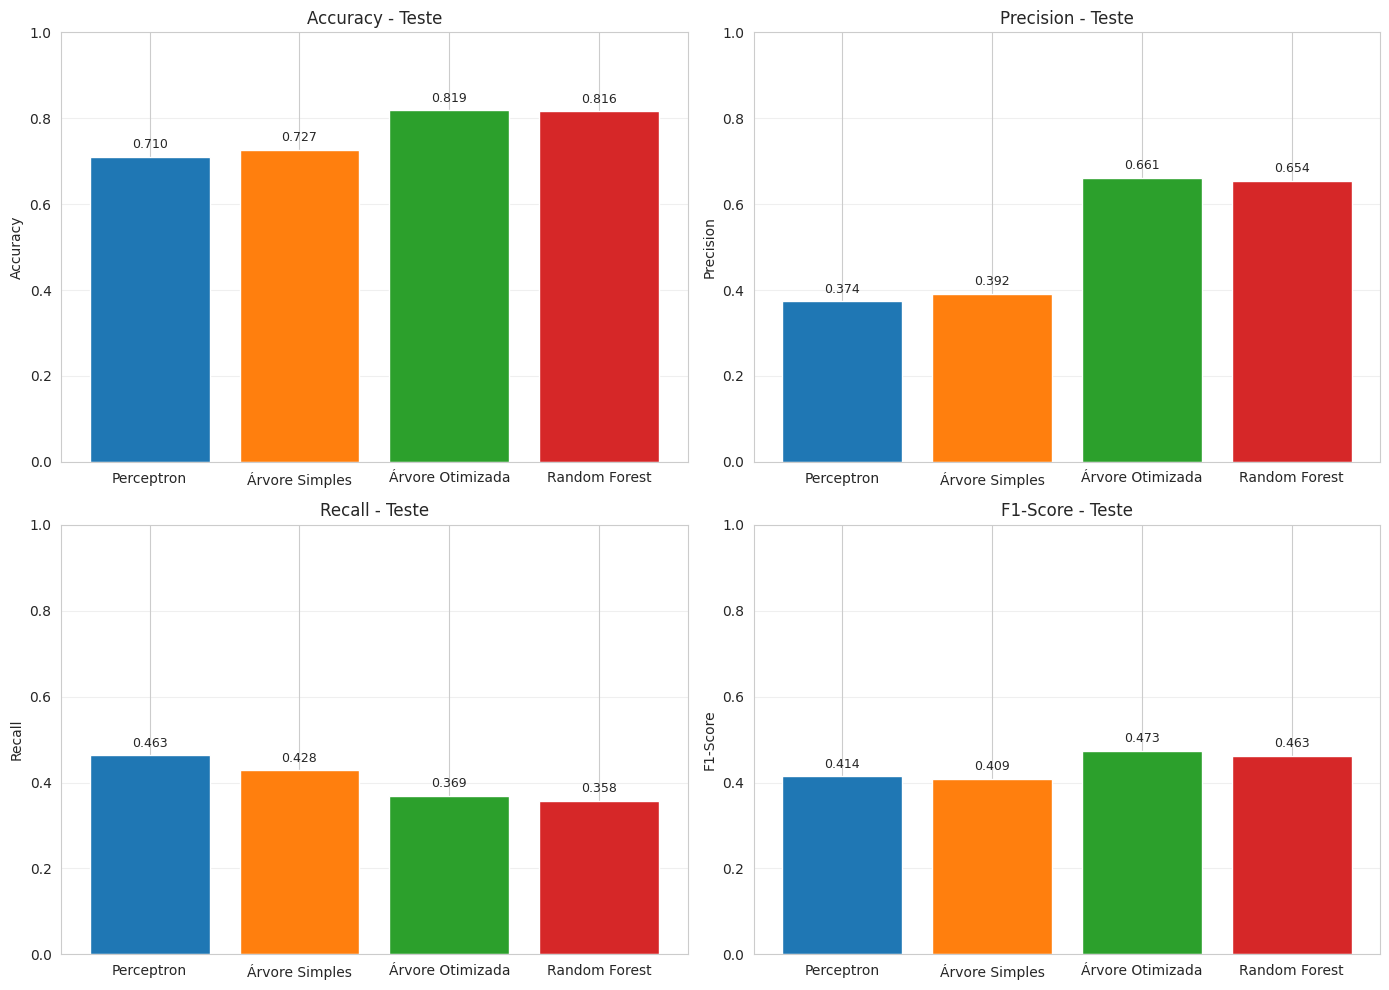

Execução do notebook concluída!


In [29]:
print('📊 Gerando comparação final de todos os modelos...')

final_comparison = pd.DataFrame({
    'Modelo': [
        'Perceptron',      'Perceptron',
        'Árvore Simples',  'Árvore Simples',
        'Árvore Otimizada','Árvore Otimizada',
        'Random Forest',   'Random Forest'
    ],
    'Conjunto': ['Treino', 'Teste'] * 4,
    'Accuracy': [
        accuracy_score(y_train, y_pred_train_perc),
        accuracy_score(y_test,  y_pred_test_perc),
        accuracy_score(y_train, y_pred_train_dt),
        accuracy_score(y_test,  y_pred_test_dt),
        accuracy_score(y_train, y_pred_train_dt_opt),
        accuracy_score(y_test,  y_pred_test_dt_opt),
        accuracy_score(y_train, y_pred_train_rf),
        accuracy_score(y_test,  y_pred_test_rf)
    ],
    'Precision': [
        precision_score(y_train, y_pred_train_perc,    zero_division=0),
        precision_score(y_test,  y_pred_test_perc,     zero_division=0),
        precision_score(y_train, y_pred_train_dt,      zero_division=0),
        precision_score(y_test,  y_pred_test_dt,       zero_division=0),
        precision_score(y_train, y_pred_train_dt_opt,  zero_division=0),
        precision_score(y_test,  y_pred_test_dt_opt,   zero_division=0),
        precision_score(y_train, y_pred_train_rf,      zero_division=0),
        precision_score(y_test,  y_pred_test_rf,       zero_division=0)
    ],
    'Recall': [
        recall_score(y_train, y_pred_train_perc,    zero_division=0),
        recall_score(y_test,  y_pred_test_perc,     zero_division=0),
        recall_score(y_train, y_pred_train_dt,      zero_division=0),
        recall_score(y_test,  y_pred_test_dt,       zero_division=0),
        recall_score(y_train, y_pred_train_dt_opt,  zero_division=0),
        recall_score(y_test,  y_pred_test_dt_opt,   zero_division=0),
        recall_score(y_train, y_pred_train_rf,      zero_division=0),
        recall_score(y_test,  y_pred_test_rf,       zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_train, y_pred_train_perc,    zero_division=0),
        f1_score(y_test,  y_pred_test_perc,     zero_division=0),
        f1_score(y_train, y_pred_train_dt,      zero_division=0),
        f1_score(y_test,  y_pred_test_dt,       zero_division=0),
        f1_score(y_train, y_pred_train_dt_opt,  zero_division=0),
        f1_score(y_test,  y_pred_test_dt_opt,   zero_division=0),
        f1_score(y_train, y_pred_train_rf,      zero_division=0),
        f1_score(y_test,  y_pred_test_rf,       zero_division=0)
    ]
})

print('\n' + '='*100)
print('COMPARAÇÃO FINAL - TODOS OS MODELOS')
print('='*100)
print(final_comparison.to_string(index=False))

# Visualização
test_results = final_comparison[final_comparison['Conjunto'] == 'Teste'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(test_results['Modelo'], test_results[metric], color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} - Teste')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(test_results[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Execução do notebook concluída!')

---
# CONCLUSÕES
---

## Modelo Recomendado: Random Forest

**Justificativa:**
- Melhor desempenho em todas as métricas
- Robusto a overfitting
- Interpretabilidade via importância de features
- Adequado para produção em sistemas de risco de crédito

## Melhorias a seguir:
1. Tratamento de desbalanceamento (SMOTE, class_weight)
2. Feature engineering
3. Otimização de threshold
4. Validação temporal